In [1]:
import pandas as pd
import numpy as np
import xarray as xr
import datetime as dt
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime as dt

import scipy.stats as stat

In [2]:
# Date Selector and integration window time

year = "2026"    # 2026
month = "02"     # 04
day = "10"       # 16

integration_window_min = 5

In [3]:
### DIY ASI data

#path
camera_data_root = "/home/sdoeding/analysis_scripts/retrieval_outfiles/"

#prepare dataset
data_cam = pd.read_csv(camera_data_root + "out_{0}{1}{2}.csv".format(year, month, day), delimiter=";")
data_cam["Timestamp"] = pd.to_datetime(data_cam["Timestamp"]).astype('datetime64[ns]')
data_cam.where(data_cam["BRBG_Fraction"]>0, other=np.nan, axis=0, inplace=True)
data_cam.set_index("Timestamp", inplace=True)

#resample
data_cam_resampled = data_cam.resample("{0}min".format(integration_window_min), label="right").mean()

In [4]:
### Ceilometer data (old)

#path
ceilo_data_root = "/projekt7/remsens/data_new/site-campaign/leipzig-lim/instruments/ceilim/data/"

#prepare dataset
data_cei_raw = xr.open_dataset(ceilo_data_root + "Y{0}/M{1}/{0}{1}{2}_Leipzig_CHM200114_000.nc".format(year, month, day))
data_cei_cloud = (data_cei_raw.cbh[:,0] >= 0).astype("int")

#resample
data_cei_resampled = data_cei_cloud.resample(time="{0}min".format(integration_window_min), label="right").mean() * 100
data_cei_resampled = data_cei_resampled.sel(time=data_cei_resampled.time.to_index().intersection(data_cam_resampled.index)) # filter timestamps

In [5]:
### Ceilometer data (auto)

#resample
data_cei_auto_resampled = data_cei_raw.tcc.resample(time="{0}min".format(integration_window_min), label="right").mean() / 8 * 100
data_cei_auto_resampled = data_cei_auto_resampled.sel(time=data_cei_auto_resampled.time.to_index().intersection(data_cam_resampled.index)) # filter timestamps

In [6]:
### Ceilometer data (own)

## get cloud bases over int_time ()
int_time = 120

cloud_bases_filtered = data_cei_raw.cbh[:,0]
cloud_bases_filtered = cloud_bases_filtered.where(cloud_bases_filtered>0, np.nan)
cloud_bases_avg = cloud_bases_filtered.resample(time="{0}min".format(int_time), label="right").mean(skipna=True)#avg over int_time
#cloud_bases_avg = cloud_bases_avg.dropna(dim="time")

## calculate average integration times from average cloud bases (empirical)
#integration_times = ((2.25 * cloud_bases_avg - 117) / 60).where(np.isfinite(cloud_bases_avg), 5)
integration_times = ((1.0 * cloud_bases_avg - 117) / 60).where(np.isfinite(cloud_bases_avg), 5)

print(cloud_bases_filtered)

## interpolate to get integration time for each timestamp
integration_times_interpolated = integration_times.interp(coords={"time": cloud_bases_filtered.time}, method="linear", kwargs={"fill_value":"extrapolate"})
integration_times_interpolated = integration_times_interpolated.where(integration_times_interpolated>1, 5) # fallback when no cloud present

## calculate cloud cover with individual integration times
tcc_own_left = []
tcc_own_both = []
for index, tstmp in enumerate(cloud_bases_filtered.time):

    #window
    time_period_left = cloud_bases_filtered.sel(time=slice(tstmp - pd.Timedelta(minutes=int(integration_times_interpolated[index].values)),
                                                           tstmp))

    time_period_both = cloud_bases_filtered.sel(time=slice(tstmp- pd.Timedelta(minutes=int(integration_times_interpolated[index].values)/2),
                                                           tstmp+pd.Timedelta(minutes=int(integration_times_interpolated[index].values)/2)))

    tcc_own_left.append((np.isfinite(time_period_left.values).astype("int").mean() * 100))
    tcc_own_both.append((np.isfinite(time_period_both.values).astype("int").mean() * 100))



# create new datasets
data_cei_own_left = xr.Dataset().assign_coords(time=data_cei_raw.time)
data_cei_own_left = data_cei_own_left.assign(tcc_diy=("time", tcc_own_left))

data_cei_own_both = xr.Dataset().assign_coords(time=data_cei_raw.time)
data_cei_own_both = data_cei_own_both.assign(tcc_diy=("time", tcc_own_both))

#resample
data_cei_own_left_resampled = data_cei_own_left.resample(time="{0}min".format(integration_window_min), label="right").mean()
data_cei_own_left_resampled = data_cei_own_left_resampled.sel(time=slice(data_cam_resampled.index[0], data_cam_resampled.index[-1])) # filter timestamps

data_cei_own_both_resampled = data_cei_own_both.resample(time="{0}min".format(integration_window_min), label="right").mean()
data_cei_own_both_resampled = data_cei_own_both_resampled.sel(time=slice(data_cam_resampled.index[0], data_cam_resampled.index[-1])) # filter timestamps

<xarray.DataArray 'cbh' (time: 5757)> Size: 46kB
array([ 810.,  792.,  799., ..., 2256., 2253., 2247.], shape=(5757,))
Coordinates:
  * time     (time) datetime64[ns] 46kB 2026-02-10T00:00:08 ... 2026-02-10T23...
    layer    int32 4B 1
Attributes:
    units:      m
    long_name:  cloud base height


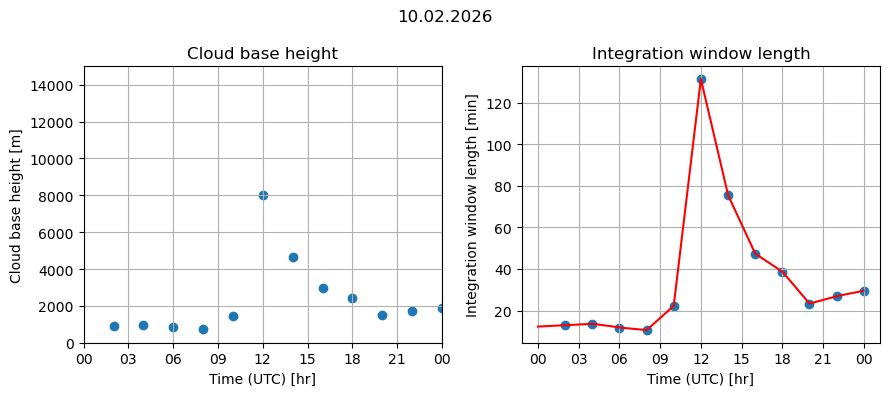

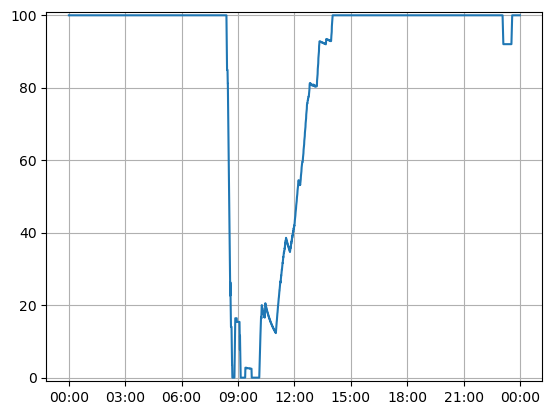

In [7]:
#plot
fig, ax = plt.subplots(nrows=1, ncols=2, tight_layout=True, figsize=(9,4))

fig.suptitle("{0}.{1}.{2}".format(day, month, year))

ax[0].scatter(cloud_bases_avg.time, cloud_bases_avg)
#ax[0].set_xlim(dt.datetime(year, month, day, 0), dt.datetime(year, month, day, 0)+dt.timedelta(days=1))
ax[0].set_ylim(0, 15000)
ax[0].set_xlim(dt.datetime(int(year), int(month), int(day)), dt.datetime(int(year), int(month), int(day)+1))
ax[0].xaxis.set_major_formatter(mpl.dates.DateFormatter("%H"))
ax[0].set_title("Cloud base height")
ax[0].set_xlabel("Time (UTC) [hr]")
ax[0].set_ylabel("Cloud base height [m]")
ax[0].grid()

ax[1].scatter(integration_times.time, integration_times)
ax[1].plot(integration_times_interpolated.time, integration_times_interpolated, color="red")
ax[1].xaxis.set_major_formatter(mpl.dates.DateFormatter("%H"))
ax[1].set_title("Integration window length")
ax[1].set_xlabel("Time (UTC) [hr]")
ax[1].set_ylabel("Integration window length [min]")
ax[1].grid()

fig.savefig("ceilometer_inttimes_{0}{1}{2}".format(year, month, day))



plt.figure()
plt.plot(data_cei_own_left.time, data_cei_own_left.tcc_diy)
plt.ylim(-1,101)
plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
plt.grid()

In [20]:
# import ampycloud as apc
# from ampycloud.utils import mocker
# from ampycloud.plots import diagnostic

# fraction_collector = []
# min5_timestamps = []

# for timeslice in data_cei_raw.resample(time="10min", label="right"):

#     work_ds = timeslice[1]
#     min5_timestamps.append(timeslice[0])

#     last_time = work_ds.time[-1].values
    
#     #timedeltas
#     dt_collector = (work_ds.time.values-last_time) / np.timedelta64(1, "ms") / 1000
    
#     #heights --> required in ft
#     height_collector = work_ds.cbh[:,0].where(work_ds.cbh[:,0]>0, np.nan).values * 3.281
    
#     #type (1-->first cloud base, 0-->no cloud base)
#     type_collector = (work_ds.cbh[:,0]).astype("int")
    
#     #ceilo
#     ceilo_collector = pd.Series(np.full(len(work_ds.time), "1"), dtype="string")
    
#     df_apc = pd.DataFrame({"dt":dt_collector, "height":height_collector, "type":type_collector, "ceilo":ceilo_collector})
#     chunk = apc.run(df_apc,geoloc='LIM - {0}.{1}.{2}'.format(day,month,year), ref_dt=last_time)

#     fraction_collector.append(chunk.layers["perc"].values.sum())

# print(fraction_collector)

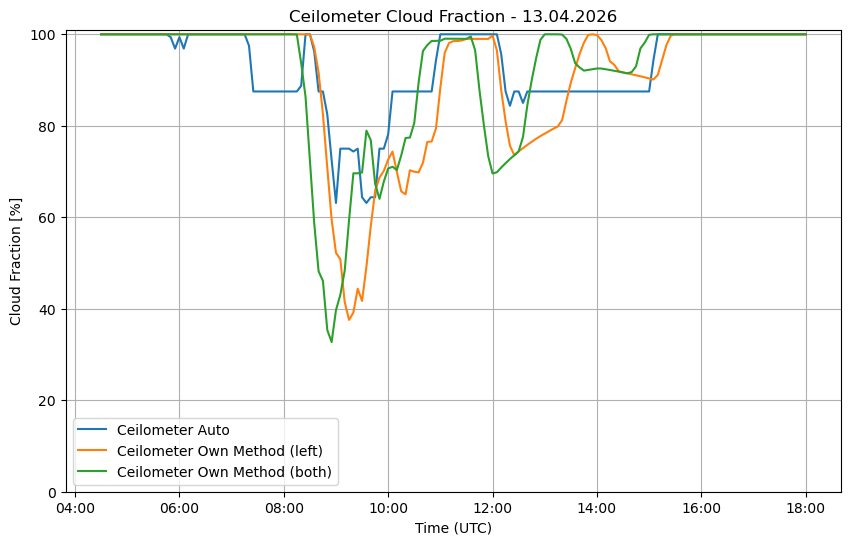

In [25]:
plt.figure(figsize=(10,6))

#plt.plot(data_cei_resampled.time, data_cei_resampled, label="Ceilometer old", color="gray", alpha=0.3, linestyle="--")
plt.plot(data_cam_resampled.index, data_cam_resampled["BRBG_Fraction"], label="DIY ASI")
plt.plot(data_cei_auto_resampled.time, data_cei_auto_resampled, label="Ceilometer Auto")
plt.plot(data_cei_own_left_resampled.time, data_cei_own_left_resampled.tcc_diy, label="Ceilometer Own Method (left)")
plt.plot(data_cei_own_both_resampled.time, data_cei_own_both_resampled.tcc_diy, label="Ceilometer Own Method (both)")
#plt.plot(min5_timestamps, fraction_collector, label="ampycloud - 5min")
plt.ylim(0,101)


plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
plt.xlabel("Time (UTC)")
plt.ylabel("Cloud Fraction [%]")
plt.title("Ceilometer Cloud Fraction - {0}.{1}.{2}".format(day, month, year))
#plt.legend(bbox_to_anchor=(1, 0.5), loc="center left")
plt.legend()
plt.grid()
#plt.xlim(dt.datetime(2026,4,23,8,0,0), dt.datetime(2026,4,23,10,0,0))

plt.savefig("ceilometer_too_long.png")


# plt.figure(figsize=(12,3))
# plt.plot(data_cei_raw.time, data_cei_raw.cbh[:,0]>0)
# plt.gca().xaxis.set_major_formatter(mpl.dates.DateFormatter("%H:%M"))
# plt.grid()
# plt.xlim(dt.datetime(2026,2,27,6), dt.datetime(2026,2,27,12))